# Comparing the two models

This notebook contains a minimal comparison between two in-built models `TaylorT2Ecc` and `TaylorT3Spin` in their common limit (quasicircular, spin-zero).

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from pygwtf.generator import AnalyticTimeFrequencyWaveform
from pygwtf.models import TaylorT2Ecc, TaylorT3Spin

In [4]:
dT = 86400 / 4  # 6 hours
nT = 365 * 4  # 1 year
dt = 5
dF = 1 / dT
fmax = 1 / (2 * dt) # Nyquist frequency for the time-domain data

nF = int((fmax)/ dF) + 1 # Number of frequency bins needed to cover the Nyquist frequency.

config = {
    "dT": dT,
    "nT": nT,
    "dt": dt,
    "dF": dF,
    "nF": nF,
    "kernel_width": 100,  # number of frequency bins to use in the fresnel kernel
}

First, let's look at the transverse-traceless polarisations. This is set by passing `tdi_type=None` (the default).

In [5]:
ecc_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=None,
)

spin_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT3Spin,
    config=config,
    tdi_type=None,
)

Spacecraft light travel times not supplied. Falling back to analytic calculation
Spacecraft light travel times not supplied. Falling back to analytic calculation


We can generate waveforms by calling the generator.

In [6]:
ecc_generator.model.parameters, spin_generator.model.parameters

(['M', 'eta', 'cosi', 'e0', 'D', 'f0', 'phi_coal'],
 ['M', 'eta', 'cosi', 'D', 'f0', 's1', 's2', 'phi_coal'])

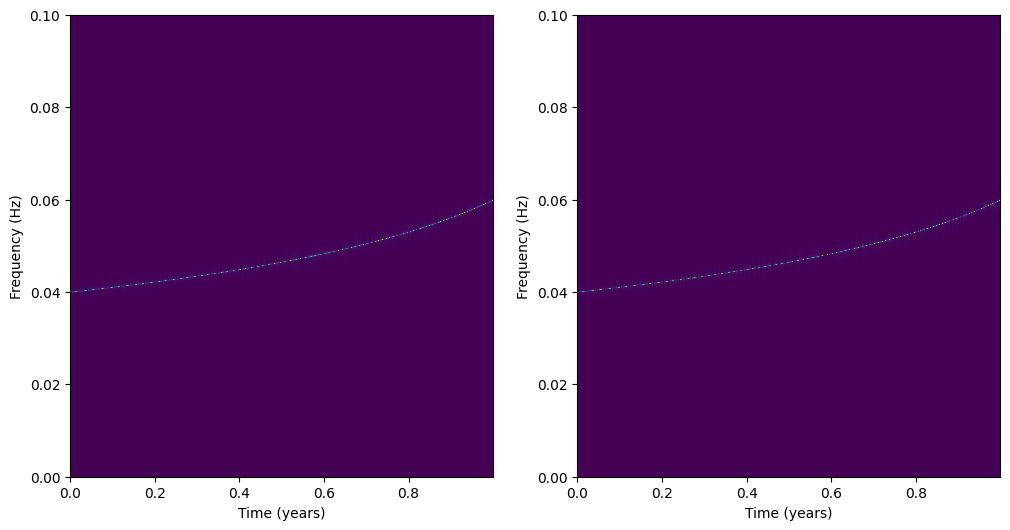

In [17]:
pars = {
    "M": 30,
    "eta": 0.25,
    "cosi": 0.5,
    "e0": 0,
    "D": 1e3,
    "f0": 4e-2,
    "phi_coal": 0.1,
    "s1": 0,
    "s2": 0,
}

tf_ecc = ecc_generator(pars)
tf_spin = spin_generator(pars)

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.pcolormesh(
    ecc_generator.t_tranche/(365.25*24*3600), ecc_generator.f_tranche, np.abs(tf_ecc[:, :, 0].T)
)
plt.xlabel("Time (years)")
plt.ylabel("Frequency (Hz)")
plt.subplot(122)
plt.pcolormesh(
    spin_generator.t_tranche/(365.25*24*3600),
    spin_generator.f_tranche,
    np.abs(tf_spin[:, :, 0].T),
)
plt.xlabel("Time (years)")
plt.ylabel("Frequency (Hz)")
plt.show()


Mismatch between the two waveforms, assuming a flat PSD:

In [18]:
mismatch = (
    1
    - np.abs((tf_ecc.conj() * tf_spin).sum())
    / (tf_ecc.conj() * tf_ecc).real.sum() ** 0.5
    / (tf_spin.conj() * tf_spin).real.sum() ** 0.5
)

print(f"Mismatch between TaylorT2Ecc and TaylorT3Spin: {mismatch:.2e}")

Mismatch between TaylorT2Ecc and TaylorT3Spin: 2.39e-05
